
# Exploration Notebook

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from pathlib import Path

In [2]:
# Plot options & location
sns.set(style="whitegrid", context="notebook", rc={"figure.figsize": (10, 5)})

PROJECT_ROOT = Path().resolve().parent
NOTEBOOK_DIR = Path().resolve()

FIG_DIR = NOTEBOOK_DIR / "figures"
os.makedirs(FIG_DIR, exist_ok=True)


In [ ]:
DATA_PATH = Path("../data/processed/modeling_dataset_ml.csv")

df = pd.read_csv(DATA_PATH)
#df.head()
df.shape

(1954192, 29)

## Initial tests

In [23]:
# Any temporal patterns in the data?
df.groupby("day_of_week")["crash_occurred"].mean()

# Crashes occur most on Fridays

day_of_week
0    0.499878
1    0.504500
2    0.501700
3    0.510016
4    0.524245
5    0.492449
6    0.463089
Name: crash_occurred, dtype: float64

In [8]:
df[["crashes_last_7_days", "crashes_last_30_days"]].describe()

,crashes_last_7_days,crashes_last_30_days
count,1.954192e+06,1.954192e+06
mean,2.706159e+00,7.293965e+00
std,3.296063e+00,1.123304e+01
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,7.000000e+00,1.100000e+01
max,2.200000e+01,7.300000e+01


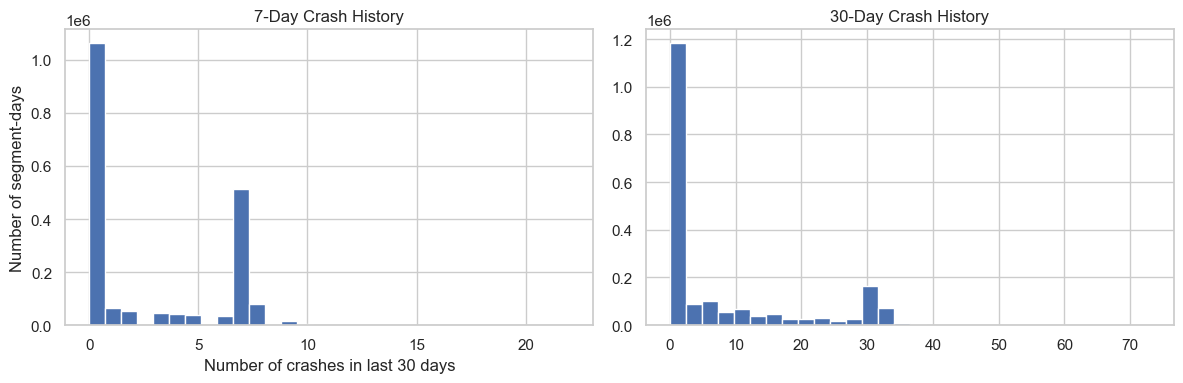

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["crashes_last_7_days"].hist(bins=30, ax=axes[0])
axes[0].set_title("7-Day Crash History")
axes[0].set_xlabel("Number of crashes in last 7 days")
axes[0].set_ylabel("Number of segment-days")

df["crashes_last_30_days"].hist(bins=30, ax=axes[1])
axes[1].set_title("30-Day Crash History")
axes[0].set_xlabel("Number of crashes in last 30 days")
axes[0].set_ylabel("Number of segment-days")

plt.tight_layout()
plt.savefig(FIG_DIR / "lag_feature_histograms.png", dpi=150, bbox_inches="tight")



## Crash Correlation

In [ ]:
# Feature correlations
df.corr(numeric_only=True)["crash_occurred"].sort_values(ascending=False).head(15)

crash_occurred          1.000000
crash_count             0.977090
crashes_last_7_days     0.821028
crashes_last_30_days    0.649332
road_motorway           0.177693
segment_length          0.175037
road_secondary          0.121839
road_primary            0.108230
road_trunk              0.028054
rain_indicator          0.014103
sin_day_of_week         0.013288
precipitation_sum       0.007320
windspeed_10m_max       0.006116
temperature_2m_mean     0.006112
month                   0.001344
Name: crash_occurred, dtype: float64

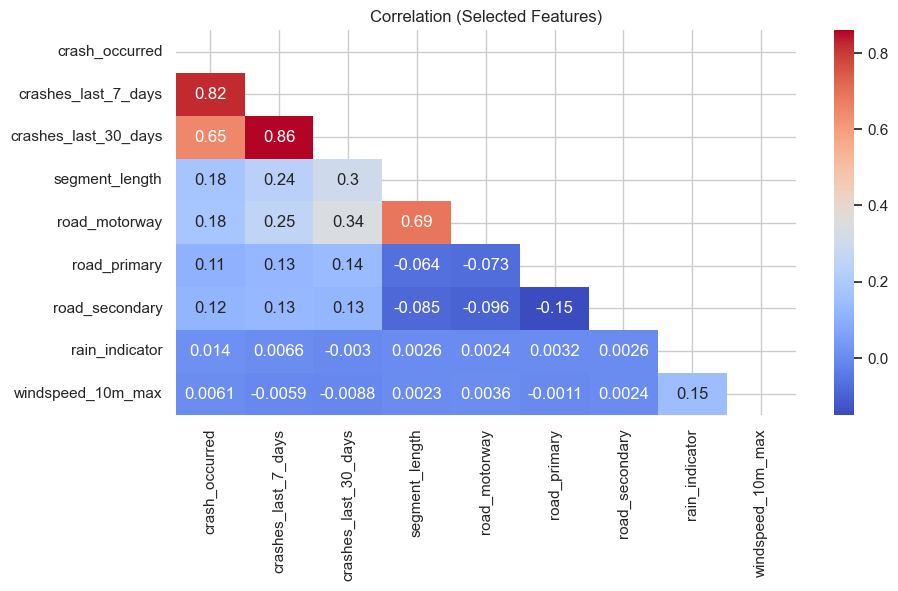

In [20]:
# Checking for any relationships between key features

subset = df[[
    "crash_occurred",
    "crashes_last_7_days",
    "crashes_last_30_days",
    "segment_length",
    "road_motorway",
    "road_primary",
    "road_secondary",
    "rain_indicator",
    "windspeed_10m_max"
]]
corr_sub = subset.corr()
mask = np.triu(np.ones_like(corr_sub, dtype=bool))

sns.heatmap(corr_sub, mask=mask, annot=True, cmap="coolwarm")
plt.title("Correlation (Selected Features)")
plt.savefig(FIG_DIR / "correlation_subset.png", dpi=150, bbox_inches="tight")


## Univariate ROC-AUC


In [13]:
from sklearn.metrics import roc_auc_score

auc_scores = {}
for col in df.select_dtypes(include=["number"]).columns:
    if col != "crash_occurred":
        try:
            auc_scores[col] = roc_auc_score(df["crash_occurred"], df[col])
        except:
            pass

pd.Series(auc_scores).sort_values(ascending=False).head(15)


crash_count             1.000000
crashes_last_7_days     0.956845
crashes_last_30_days    0.956845
segment_length          0.583102
road_secondary          0.545354
road_motorway           0.536692
road_primary            0.532712
precipitation_sum       0.508859
sin_day_of_week         0.507356
rain_indicator          0.507024
temperature_2m_mean     0.503851
windspeed_10m_max       0.503294
road_trunk              0.502031
month                   0.500767
road_busway             0.499983
dtype: float64

## NYC Street Network Map

In [10]:
# Grab the Geopandas 
GEOJSON_PATH = Path("../data/raw/nyc_street_network.geojson")
segments = gpd.read_file(GEOJSON_PATH)


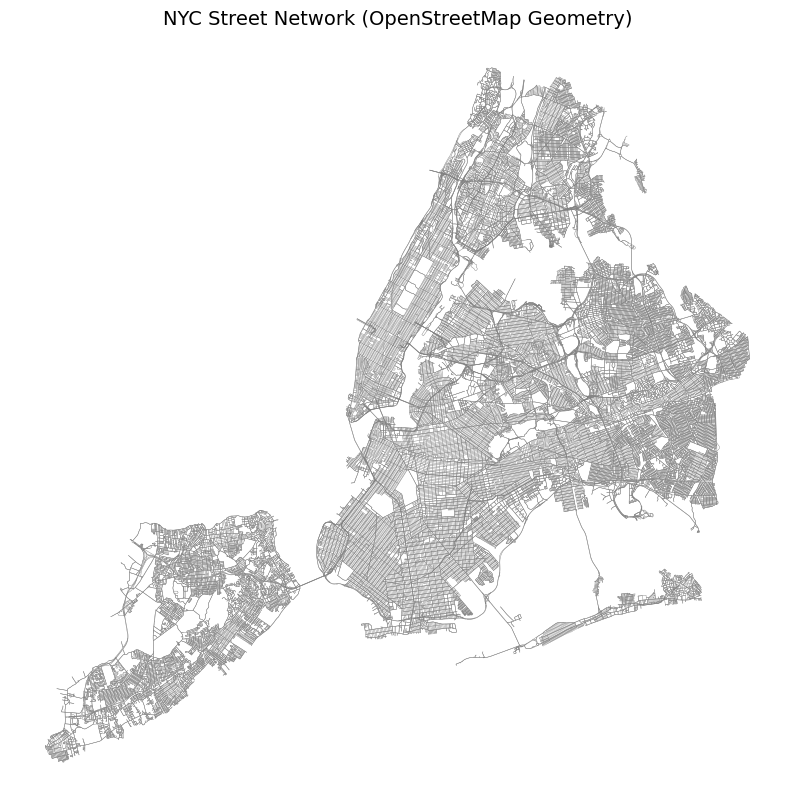

In [11]:
# Plotting the segments
fig, ax = plt.subplots(figsize=(10,10))
segments.plot(ax=ax, linewidth=0.3, color="gray")

ax.set_title("NYC Street Network (OpenStreetMap Geometry)", fontsize=14)
ax.set_axis_off()
plt.show()

In [7]:
segments.columns

Index(['u', 'v', 'key', 'length', 'highway', 'name', 'geometry'], dtype='str')

In [13]:
# How about with crashes
CRASH_PATH = Path("../data/interim/crashes_with_segments.geojson")
crashes = gpd.read_file(CRASH_PATH)

crashes_with_geom = crashes.merge(
    segments[["u", "v", "key", "geometry"]],
    on=["u", "v", "key"],
    how="left"
)


In [30]:
# Calculating crash totals for each road's segment_id
crash_totals = (
    crashes.groupby("segment_id")
    .size()
    .reset_index(name="crash_count")
)

# Merge again
segment_geoms = segments.copy()
segment_geoms["segment_id"] = segment_geoms.index.astype(str)

segment_crashes = segment_geoms.merge(
    crash_totals,
    on="segment_id",
    how="left"
)

segment_crashes["crash_count"] = segment_crashes["crash_count"].fillna(0)
segment_crashes["crash_bin"] = pd.qcut(
    segment_crashes["crash_count"],
    q=10,
    labels=False,
    duplicates="drop"
)


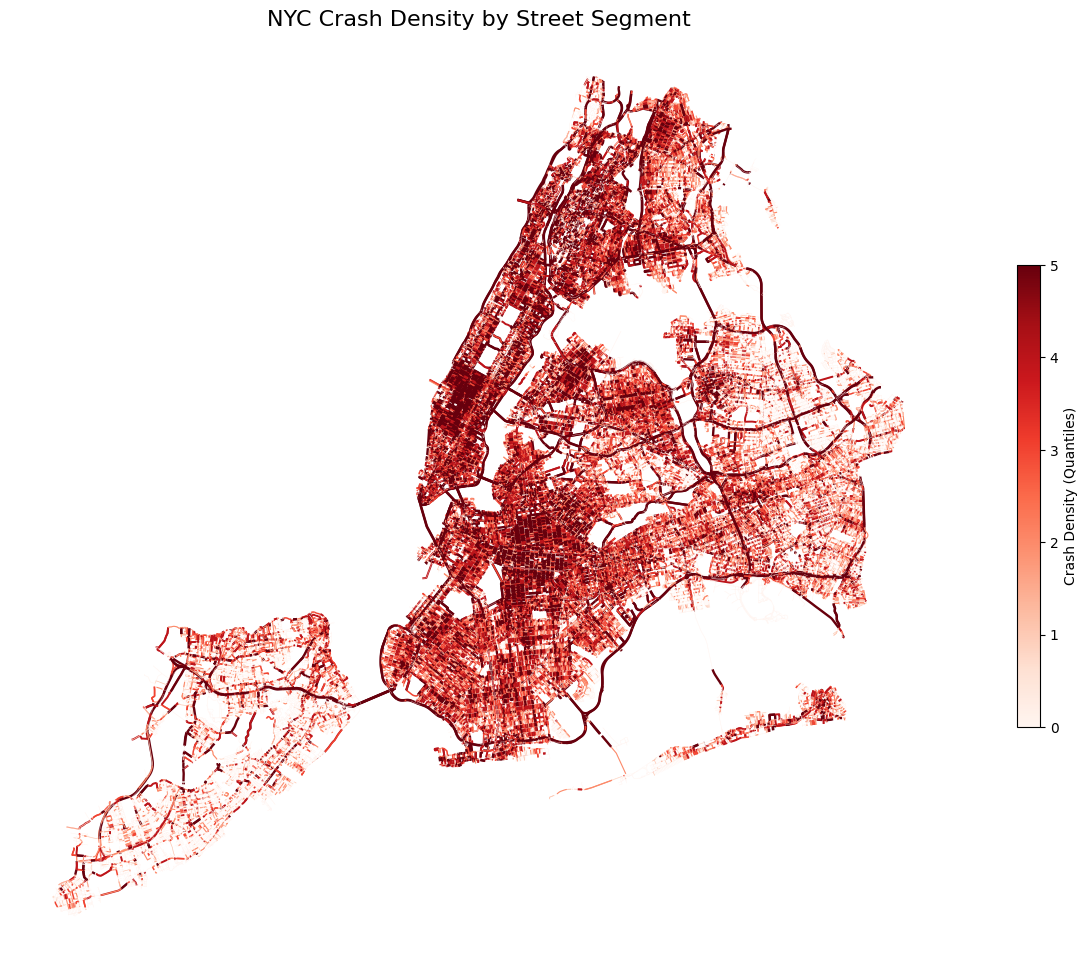

In [31]:
# Segment crash heat map
fig, ax = plt.subplots(figsize=(18, 12))

segment_crashes.plot(
    ax=ax,
    column="crash_bin",
    cmap="Reds",
    linewidth=segment_crashes["crash_bin"].apply(lambda x: 0.2 + x*0.3),
    legend=True,
    legend_kwds={"label": "Crash Density (Quantiles)","shrink": 0.5}
)

ax.set_title("NYC Crash Density by Street Segment", fontsize=16)
ax.set_axis_off()
plt.show()
